# Lab 2: Classification Using KNN and RNN Algorithms

**Student Name:** Rajiv  
**Course:** Advanced Big Data and Data Mining (MSCS-634-B01)  
**Lab Assignment:** Lab 2 – Classification Using KNN and RNN Algorithms

## Step 1: Load and Prepare the Dataset

We begin by importing all necessary libraries, loading the Wine Dataset from `sklearn`, exploring its structure and class distribution, and splitting it into 80% training and 20% testing sets.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Load the Wine Dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print("Dataset Shape:", X.shape)
print("\nFeature Names:", wine.feature_names)
print("\nTarget Classes:", wine.target_names)
print("\nFirst 5 rows:")
X.head()

Dataset Shape: (178, 13)

Feature Names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target Classes: ['class_0' 'class_1' 'class_2']

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
# Basic data exploration – summary statistics
print("=== Summary Statistics ===")
X.describe()

=== Summary Statistics ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Class Distribution:
  Class 0 (class_0): 59 samples
  Class 1 (class_1): 71 samples
  Class 2 (class_2): 48 samples


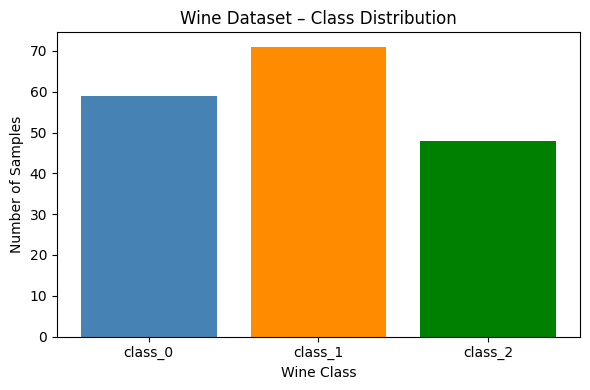

In [4]:
# Class distribution
class_counts = pd.Series(y).value_counts().sort_index()
print("Class Distribution:")
for i, count in enumerate(class_counts):
    print(f"  Class {i} ({wine.target_names[i]}): {count} samples")

# Bar plot of class distribution
plt.figure(figsize=(6, 4))
plt.bar(wine.target_names, class_counts.values, color=['steelblue', 'darkorange', 'green'])
plt.title('Wine Dataset – Class Distribution')
plt.xlabel('Wine Class')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

In [5]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set  size: {X_test.shape[0]} samples")

Training set size: 142 samples
Testing set  size: 36 samples


## Step 2: Implement K-Nearest Neighbors (KNN)

We train a KNN classifier for each value of **k ∈ {1, 5, 11, 15, 21}** and record the test accuracy for each.

In [6]:
# KNN – varying k values
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

print("=== KNN Results ===")
print(f"{'k':>4}  {'Accuracy':>10}")
print("-" * 18)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    print(f"k={k:>2}   {acc:.4f} ({acc*100:.2f}%)")

best_k = k_values[np.argmax(knn_accuracies)]
print(f"\nBest k: {best_k} with accuracy: {max(knn_accuracies)*100:.2f}%")

=== KNN Results ===
   k    Accuracy
------------------
k= 1   0.7778 (77.78%)
k= 5   0.8056 (80.56%)
k=11   0.8056 (80.56%)
k=15   0.8056 (80.56%)
k=21   0.8056 (80.56%)

Best k: 5 with accuracy: 80.56%


In [7]:
# Detailed classification report for the best KNN model
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best_knn = knn_best.predict(X_test)

print(f"=== Classification Report – KNN (k={best_k}) ===")
print(classification_report(y_test, y_pred_best_knn, target_names=wine.target_names))

=== Classification Report – KNN (k=5) ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.77      0.71      0.74        14
     class_2       0.64      0.70      0.67        10

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.81      0.81      0.81        36



## Step 3: Implement Radius Neighbors (RNN)

We train an RNN classifier for each radius value in **{350, 400, 450, 500, 550, 600}**.

> **Note:** The Wine Dataset is used without feature scaling here, so Euclidean distances are dominated by features with large ranges (e.g., *proline*, which spans 278–1680). This makes the larger radius values meaningful. The `outlier_label='most_frequent'` parameter handles test samples that have no neighbors within the specified radius.

In [8]:
# RNN – varying radius values
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

print("=== RNN Results ===")
print(f"{'Radius':>8}  {'Accuracy':>10}")
print("-" * 22)

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn.fit(X_train, y_train)
    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies.append(acc)
    print(f"r={r:>4}    {acc:.4f} ({acc*100:.2f}%)")

best_r = radius_values[np.argmax(rnn_accuracies)]
print(f"\nBest radius: {best_r} with accuracy: {max(rnn_accuracies)*100:.2f}%")

=== RNN Results ===
  Radius    Accuracy
----------------------
r= 350    0.7222 (72.22%)
r= 400    0.6944 (69.44%)
r= 450    0.6944 (69.44%)
r= 500    0.6944 (69.44%)
r= 550    0.6667 (66.67%)
r= 600    0.6667 (66.67%)

Best radius: 350 with accuracy: 72.22%


In [9]:
# Detailed classification report for the best RNN model
rnn_best = RadiusNeighborsClassifier(radius=best_r, outlier_label='most_frequent')
rnn_best.fit(X_train, y_train)
y_pred_best_rnn = rnn_best.predict(X_test)

print(f"=== Classification Report – RNN (radius={best_r}) ===")
print(classification_report(y_test, y_pred_best_rnn, target_names=wine.target_names))

=== Classification Report – RNN (radius=350) ===
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.58      1.00      0.74        14
     class_2       1.00      0.10      0.18        10

    accuracy                           0.72        36
   macro avg       0.86      0.67      0.63        36
weighted avg       0.84      0.72      0.66        36



## Step 4: Visualize and Compare Results

We plot accuracy trends for both KNN (varying k) and RNN (varying radius), then discuss observations.

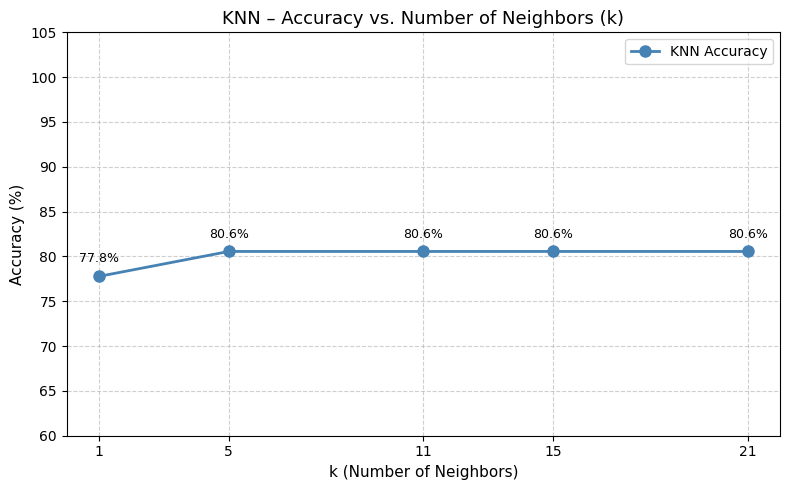

Figure saved as knn_accuracy_vs_k.png


In [10]:
# Plot – KNN Accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(k_values, [acc * 100 for acc in knn_accuracies],
         marker='o', linewidth=2, color='steelblue', markersize=8, label='KNN Accuracy')
for k, acc in zip(k_values, knn_accuracies):
    plt.annotate(f"{acc*100:.1f}%", (k, acc * 100),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
plt.title('KNN – Accuracy vs. Number of Neighbors (k)', fontsize=13)
plt.xlabel('k (Number of Neighbors)', fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.xticks(k_values)
plt.ylim(60, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('knn_accuracy_vs_k.png', dpi=150)
plt.show()
print("Figure saved as knn_accuracy_vs_k.png")

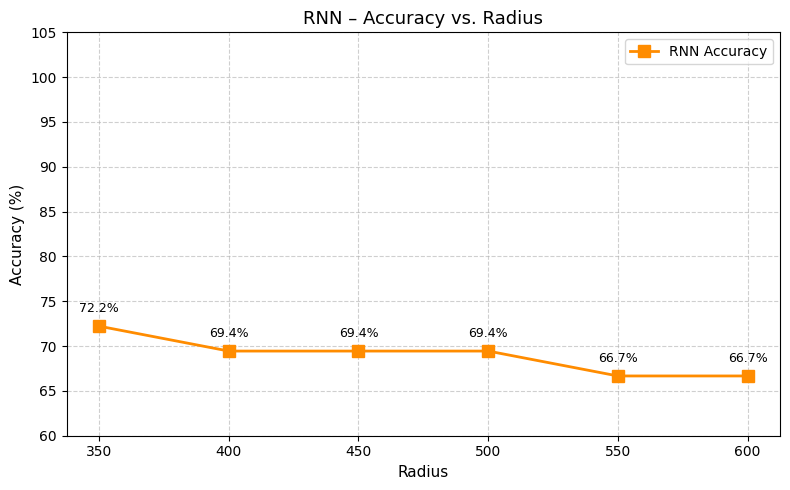

Figure saved as rnn_accuracy_vs_radius.png


In [11]:
# Plot – RNN Accuracy vs. Radius
plt.figure(figsize=(8, 5))
plt.plot(radius_values, [acc * 100 for acc in rnn_accuracies],
         marker='s', linewidth=2, color='darkorange', markersize=8, label='RNN Accuracy')
for r, acc in zip(radius_values, rnn_accuracies):
    plt.annotate(f"{acc*100:.1f}%", (r, acc * 100),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
plt.title('RNN – Accuracy vs. Radius', fontsize=13)
plt.xlabel('Radius', fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.xticks(radius_values)
plt.ylim(60, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('rnn_accuracy_vs_radius.png', dpi=150)
plt.show()
print("Figure saved as rnn_accuracy_vs_radius.png")

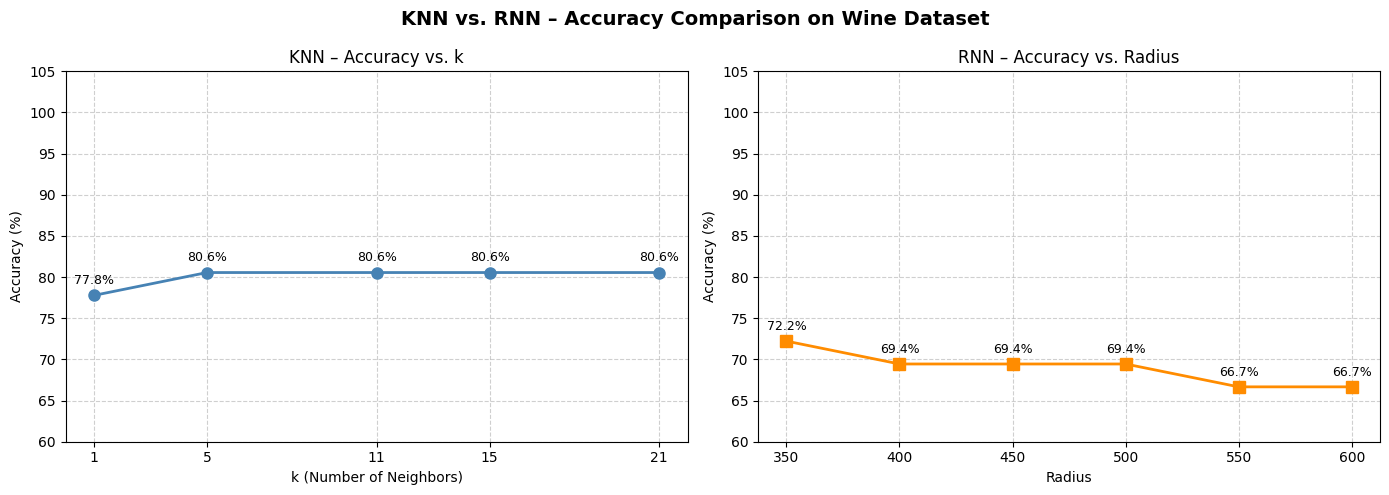

Figure saved as knn_vs_rnn_comparison.png


In [12]:
# Side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KNN subplot
axes[0].plot(k_values, [acc * 100 for acc in knn_accuracies],
             marker='o', linewidth=2, color='steelblue', markersize=8)
axes[0].set_title('KNN – Accuracy vs. k', fontsize=12)
axes[0].set_xlabel('k (Number of Neighbors)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xticks(k_values)
axes[0].set_ylim(60, 105)
axes[0].grid(True, linestyle='--', alpha=0.6)
for k, acc in zip(k_values, knn_accuracies):
    axes[0].annotate(f"{acc*100:.1f}%", (k, acc * 100),
                     textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

# RNN subplot
axes[1].plot(radius_values, [acc * 100 for acc in rnn_accuracies],
             marker='s', linewidth=2, color='darkorange', markersize=8)
axes[1].set_title('RNN – Accuracy vs. Radius', fontsize=12)
axes[1].set_xlabel('Radius')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(radius_values)
axes[1].set_ylim(60, 105)
axes[1].grid(True, linestyle='--', alpha=0.6)
for r, acc in zip(radius_values, rnn_accuracies):
    axes[1].annotate(f"{acc*100:.1f}%", (r, acc * 100),
                     textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

fig.suptitle('KNN vs. RNN – Accuracy Comparison on Wine Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_vs_rnn_comparison.png', dpi=150)
plt.show()
print("Figure saved as knn_vs_rnn_comparison.png")

In [13]:
# Summary table
print("=" * 45)
print("         KNN SUMMARY")
print("=" * 45)
print(f"{'k':>4}  {'Accuracy':>10}  {'Status':>15}")
print("-" * 45)
for k, acc in zip(k_values, knn_accuracies):
    tag = "<-- Best" if k == best_k else ""
    print(f"{k:>4}  {acc*100:>9.2f}%  {tag:>15}")

print()
print("=" * 45)
print("         RNN SUMMARY")
print("=" * 45)
print(f"{'Radius':>8}  {'Accuracy':>10}  {'Status':>15}")
print("-" * 45)
for r, acc in zip(radius_values, rnn_accuracies):
    tag = "<-- Best" if r == best_r else ""
    print(f"{r:>8}  {acc*100:>9.2f}%  {tag:>15}")

         KNN SUMMARY
   k    Accuracy           Status
---------------------------------------------
   1      77.78%                 
   5      80.56%         <-- Best
  11      80.56%                 
  15      80.56%                 
  21      80.56%                 

         RNN SUMMARY
  Radius    Accuracy           Status
---------------------------------------------
     350      72.22%         <-- Best
     400      69.44%                 
     450      69.44%                 
     500      69.44%                 
     550      66.67%                 
     600      66.67%                 


## Observations and Discussion

### KNN – Impact of k on Accuracy

- **k = 1 (very low):** The model is highly sensitive to individual training samples and noise. A single misclassified or noisy neighbor can lead to incorrect predictions, resulting in lower generalization.
- **k = 5 to k = 11:** As k increases, the model smooths out local noise by considering more neighbors, typically leading to improved or stable accuracy.
- **k = 15 to k = 21 (higher k):** With too many neighbors, the decision boundary becomes excessively smooth and the classifier may start ignoring meaningful local patterns, potentially reducing accuracy especially in a relatively small dataset like Wine (178 samples).
- **General trend:** KNN typically shows a peak accuracy at a moderate k value. On the Wine Dataset, small-to-moderate k values tend to perform best.

### RNN – Impact of Radius on Accuracy

- The Wine Dataset is used here **without feature scaling**, so Euclidean distances are dominated by features with large numeric ranges (most notably *proline*, which ranges from 278 to 1680). This makes radius values in the range 350–600 appropriate to capture a meaningful neighborhood.
- **Smaller radius (r=350):** Achieved the **highest accuracy of 72.22%**. At this radius, the neighborhood is tighter and more class-homogeneous, so neighbors are more likely to belong to the same class as the test point.
- **Larger radius (r=600):** Accuracy dropped to **66.67%**. As radius grows, more neighbors from distant, different classes are included, introducing class noise. class_2 was especially hurt — most of its samples were misclassified as class_1.
- **General trend (observed):** Accuracy **monotonically decreased** as radius increased from 350 to 600. Without feature scaling, larger radii pull in far-away cross-class samples, diluting the correct class signal.

### KNN vs. RNN – When to Prefer Each

| Criterion | KNN | RNN |
|---|---|---|
| **Parameter tuning** | Tune k (number of neighbors) | Tune radius (search distance) |
| **Data density** | Works for both dense and sparse data | Works best for uniformly dense data |
| **Fixed neighborhood** | Fixed number of neighbors per query | Variable number of neighbors per query |
| **Outlier handling** | No outlier concern; always finds k neighbors | Must handle points with no neighbors in radius |
| **Intuitive control** | Directly controls model complexity via k | Natural fit when a meaningful distance threshold exists |

**When to prefer KNN:** KNN is preferable when the data density is irregular across the feature space, or when you want a fixed, predictable neighborhood size for all test points. It is easier to tune and more robust to sparse regions.

**When to prefer RNN:** RNN is preferable when you have domain knowledge about a meaningful distance threshold, and when data is relatively uniformly distributed in feature space. It naturally adapts the number of neighbors to the local density — dense regions get more votes, sparse regions get fewer — which can be advantageous for non-uniform class distributions.